In [3]:
import jax.numpy as jnp 
import jax
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import diffrax
import equinox

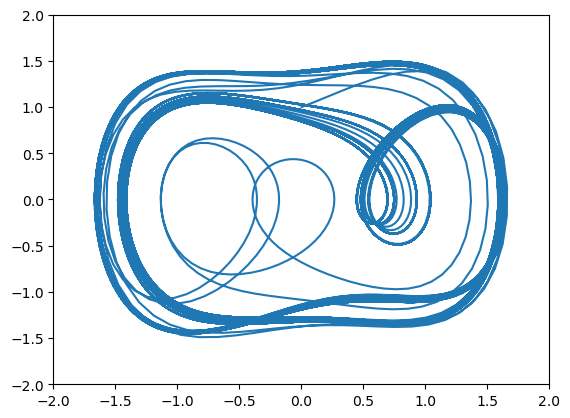

In [6]:
# Constants (fixed)
C=0.0
omega = 1.2
gamma = 1.0
alpha = 1.0
beta = -1.0

# Vector of C values
Cs = jnp.linspace(0.5, .65, 100)

def dx_dt(t, x, args):
    k = args
    return jnp.array([
        x[1],
        -beta*x[0] - k*x[1] - alpha*x[0]**3 + gamma*jnp.cos(omega*t) + C
    ])

term = diffrax.ODETerm(dx_dt)
solver = diffrax.Tsit5()
y0 = jnp.array([0.0, 1.0])
ts = jnp.linspace(0, 1000, 10000)

def solve_single(k):
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=5000,
        dt0=0.05,
        y0=y0,
        args=k,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps=1_000_000,
    )
    return sol.ys

# Vectorize over C
batched_solve = jax.vmap(solve_single)

solutions = batched_solve(Cs)

fig, ax = plt.subplots()
line, = ax.plot([], [])
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

def update(frame):
    line.set_data(
        solutions[frame, :, 0],
        solutions[frame, :, 1]
    )
    return line,

ani = animation.FuncAnimation(
    fig, update, frames=100, interval=50
)
ani.save("duffing_animationVarK.mp4", writer="ffmpeg", fps=20)